<a href="https://colab.research.google.com/github/Bpatnaik470/Bpatnaik470/blob/main/Employee_turnover_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/HR_comma_sep.csv')

# Check for missing values
missing_values = df.isnull().sum()

# Display the count of missing values for each column
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64


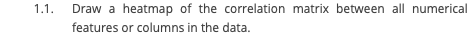

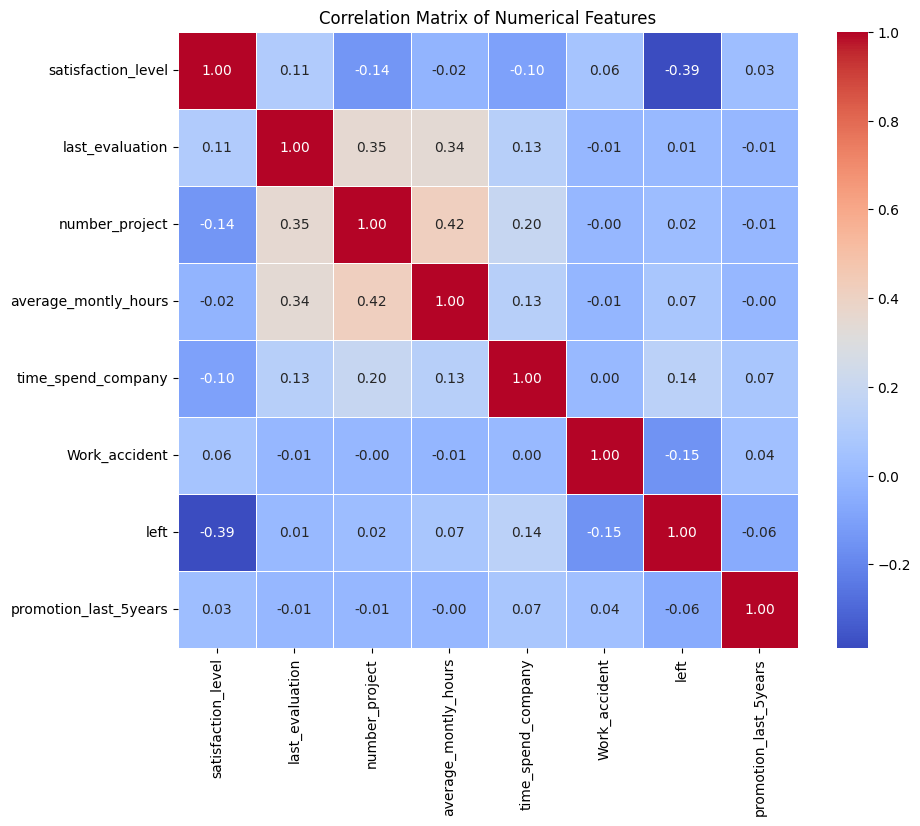

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (assuming df is already loaded in previous cells, but re-loading for completeness)
df = pd.read_csv('/content/HR_comma_sep.csv')

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Draw the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

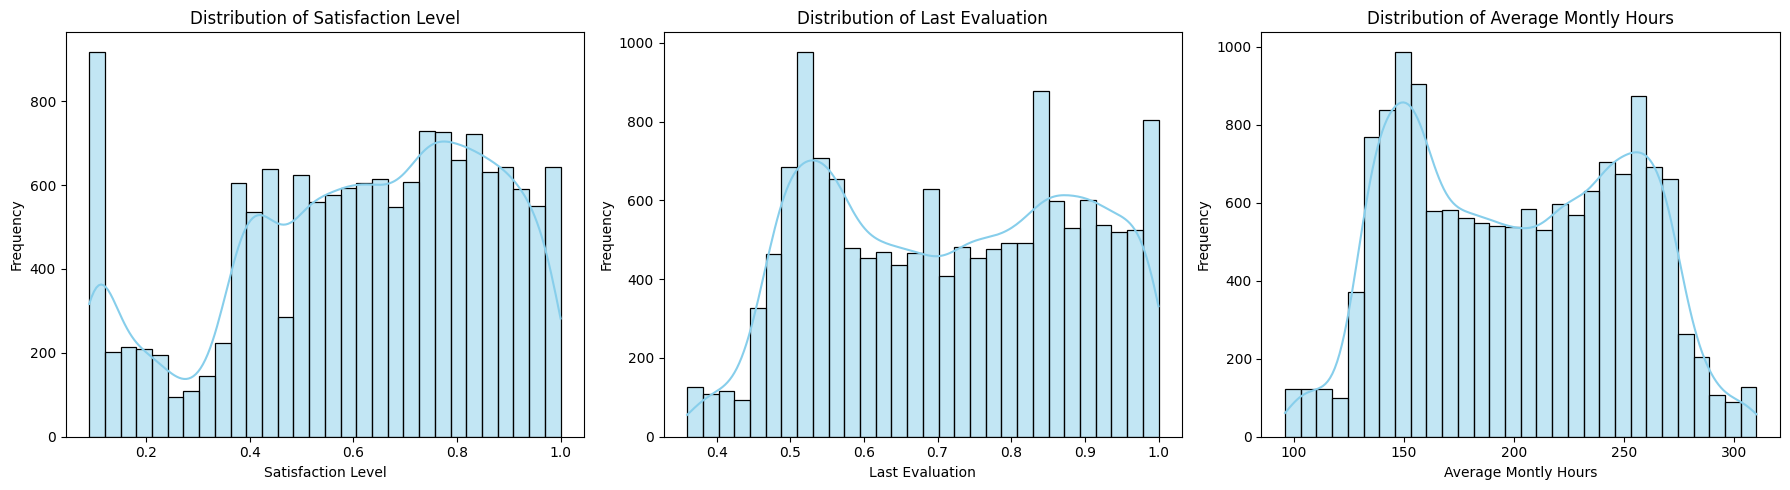

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to plot
columns_to_plot = ['satisfaction_level', 'last_evaluation', 'average_montly_hours']

# Create a figure to hold all plots
plt.figure(figsize=(18, 5))

for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(1, len(columns_to_plot), i) # Create subplots dynamically
    sns.histplot(df[column], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {column.replace("_", " ").title()}')
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

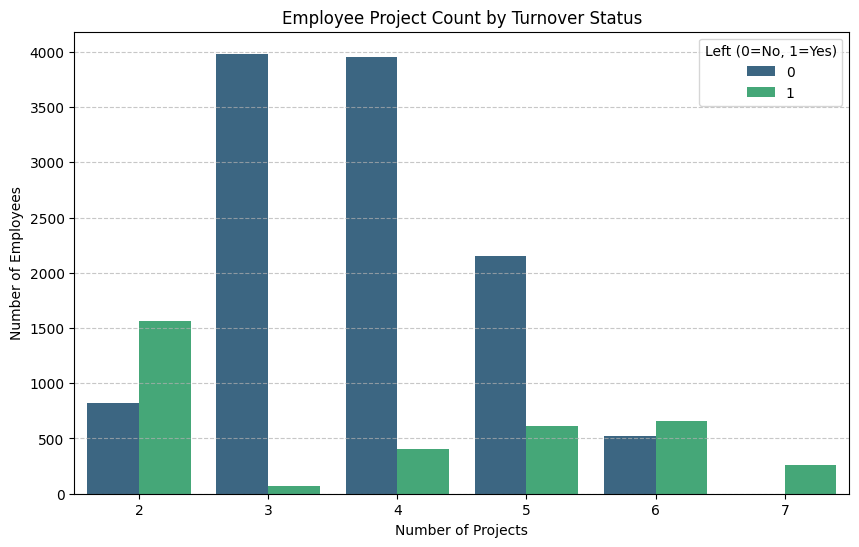

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for 'number_project' with 'left' as hue
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='number_project', hue='left', palette='viridis')
plt.title('Employee Project Count by Turnover Status')
plt.xlabel('Number of Projects')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0) # Ensure x-axis labels are readable
plt.legend(title='Left (0=No, 1=Yes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Inferences from the Employee Project Count Plot:

*   **Employees with 2 projects:** A very large number of employees who stayed (blue bars) have 2 projects, and very few employees who left (purple bars) had 2 projects. This suggests that having 2 projects might be a 'safe zone' for retention.
*   **Employees with 3, 4, and 5 projects:** The majority of employees, both those who stayed and those who left, had 3, 4, or 5 projects. The proportion of employees leaving appears higher for those with 3, 4, or 5 projects compared to those with 2 projects.
*   **Employees with 6 and 7 projects:** A significantly higher proportion of employees who left the company had 6 or 7 projects compared to those who stayed. This indicates that being assigned too many projects (e.g., 6 or 7) could be a strong predictor of an employee leaving the organization, possibly due to burnout or overwhelming workload.

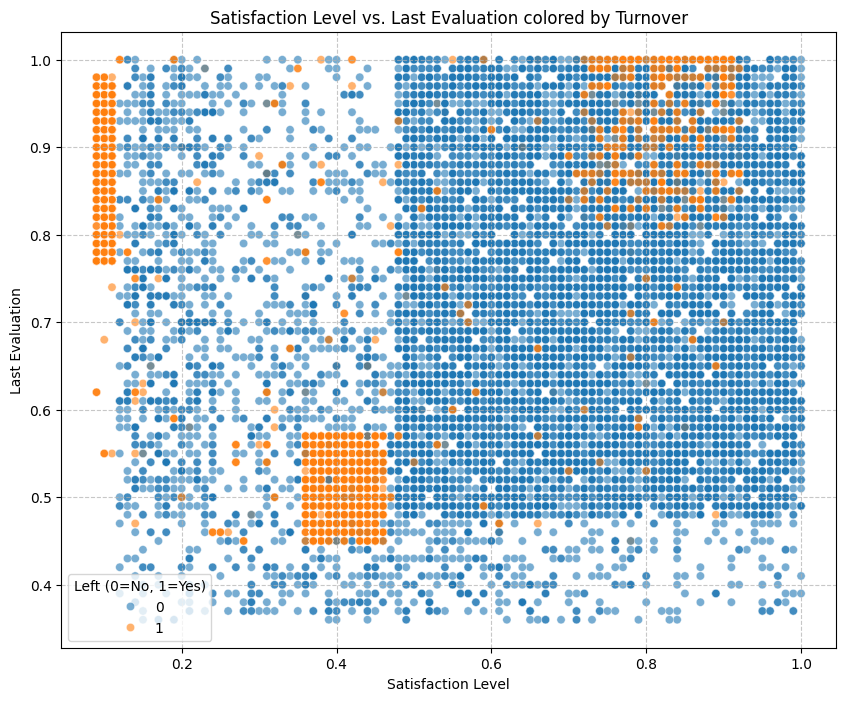

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x='satisfaction_level', y='last_evaluation', hue='left', data=df, alpha=0.6)
plt.title('Satisfaction Level vs. Last Evaluation colored by Turnover')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.legend(title='Left (0=No, 1=Yes)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Inferences from the Scatter Plot of Satisfaction Level vs. Last Evaluation:

*   **High Satisfaction, High Evaluation (Stayed):** A large cluster of employees who stayed (blue dots) have both high satisfaction levels (above 0.6) and high last evaluation scores (above 0.7).
*   **Low Satisfaction, High Evaluation (Left):** There's a noticeable group of employees who left (orange dots) with low satisfaction levels (below 0.4) but surprisingly high last evaluation scores (above 0.7). This could indicate employees who were productive but unhappy.
*   **Low Satisfaction, Low Evaluation (Left):** Another significant cluster of employees who left has both low satisfaction levels (below 0.4) and low last evaluation scores (below 0.6).
*   **High Satisfaction, Low Evaluation (Stayed):** Very few employees who left had both high satisfaction and low evaluation, suggesting this combination is generally associated with staying.
*   **Distinction of 'Left' Employees:** The plot clearly shows distinct clusters for employees who left, often characterized by either very low satisfaction or a combination of low satisfaction and high evaluation, or low evaluation and low satisfaction. This suggests that satisfaction and evaluation are key factors in understanding turnover.

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Filter for employees who left the company (where 'left' == 1)
df_left = df[df['left'] == 1].copy()

# Select features for clustering. These are typically numerical and relevant to employee performance/satisfaction.
# Based on previous explorations, 'satisfaction_level', 'last_evaluation', and 'average_montly_hours' are good candidates.
features_for_clustering = df_left[['satisfaction_level', 'last_evaluation', 'average_montly_hours', 'number_project']].copy()

# Standardize the features, which is important for K-means as it relies on distance metrics
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

# Apply K-means clustering
k = 3 # The user specified 3 clusters
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_left['cluster'] = kmeans.fit_predict(scaled_features)

print(f"Number of employees who left: {len(df_left)}")
print("Cluster distribution for employees who left:")
print(df_left['cluster'].value_counts())

# Display the first few rows with their assigned clusters
print("\nDataFrame with assigned clusters:")
display(df_left.head())

Number of employees who left: 3571
Cluster distribution for employees who left:
cluster
0    1614
2     997
1     960
Name: count, dtype: int64

DataFrame with assigned clusters:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,cluster
0,0.38,0.53,2,157,3,0,1,0,sales,low,0
1,0.80,0.86,5,262,6,0,1,0,sales,medium,2
2,0.11,0.88,7,272,4,0,1,0,sales,medium,1
3,0.72,0.87,5,223,5,0,1,0,sales,low,2
4,0.37,0.52,2,159,3,0,1,0,sales,low,0


Now that we have clustered the employees who left, let's visualize these clusters. We'll use a scatter plot, similar to the one before, but this time coloring by the assigned cluster.

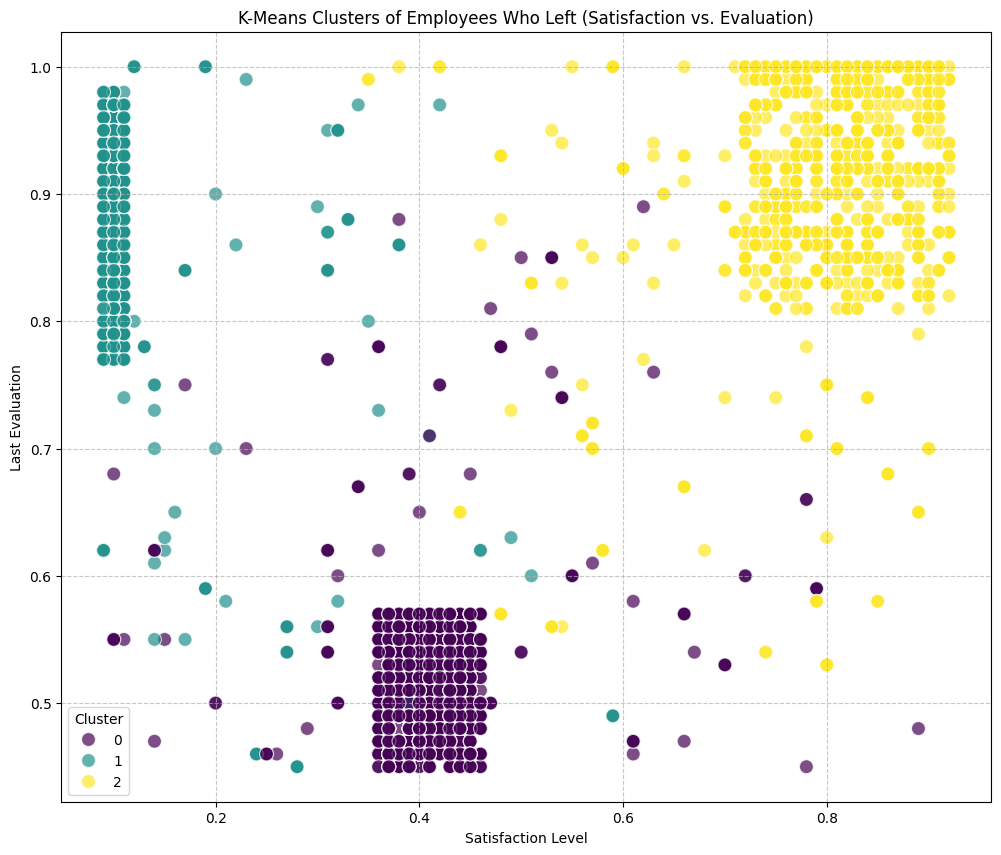

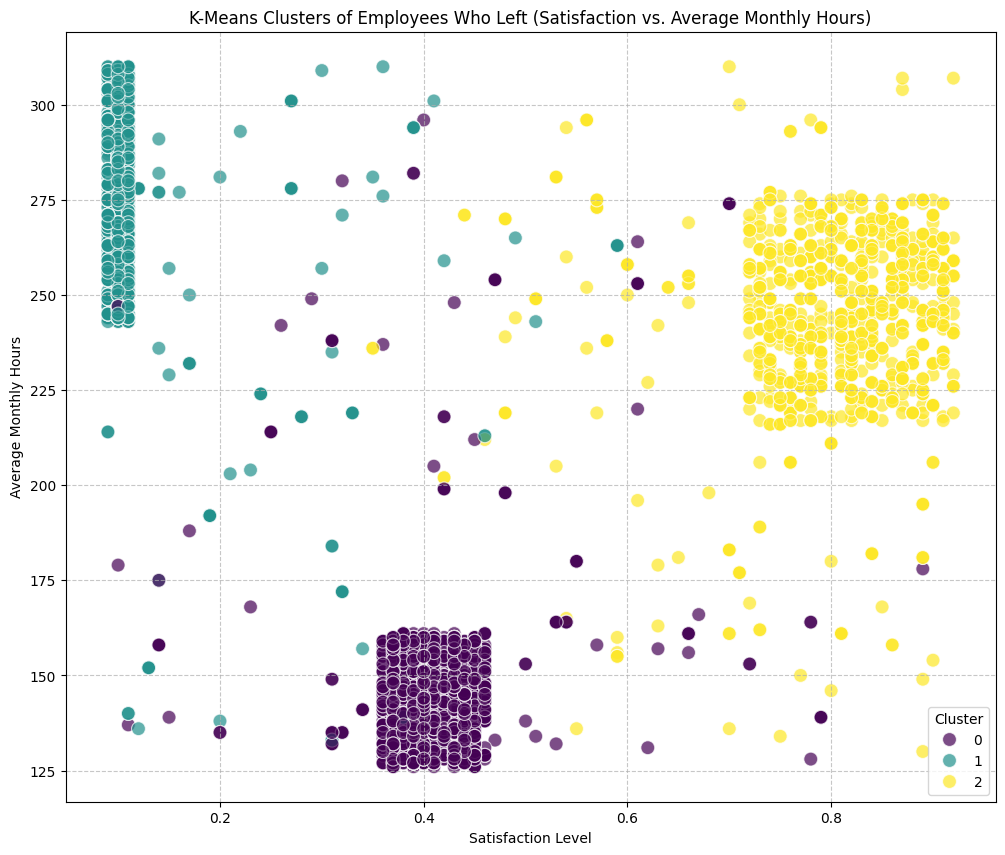

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.scatterplot(x='satisfaction_level', y='last_evaluation', hue='cluster', data=df_left, palette='viridis', s=100, alpha=0.7)
plt.title('K-Means Clusters of Employees Who Left (Satisfaction vs. Evaluation)')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# You can also visualize other combinations or use 3D plots for more features
# For example, to see average_montly_hours:
plt.figure(figsize=(12, 10))
sns.scatterplot(x='satisfaction_level', y='average_montly_hours', hue='cluster', data=df_left, palette='viridis', s=100, alpha=0.7)
plt.title('K-Means Clusters of Employees Who Left (Satisfaction vs. Average Monthly Hours)')
plt.xlabel('Satisfaction Level')
plt.ylabel('Average Monthly Hours')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Inferences from K-Means Clusters of Employees Who Left (Satisfaction vs. Evaluation):

The clustering of employees who left reveals distinct groups with different patterns of satisfaction and evaluation:

*   **Cluster 0 (Low Satisfaction, Low Evaluation):** This cluster (often represented by one of the colors, e.g., purple in `viridis` palette) typically comprises employees with both low satisfaction levels (e.g., below 0.3-0.4) and low to moderate evaluation scores (e.g., below 0.6). These employees might be genuinely unhappy and underperforming, indicating a clear case of disengagement leading to turnover.

*   **Cluster 1 (High Satisfaction, High Evaluation - but still left):** This cluster (e.g., yellow/light green) is less intuitive at first glance but crucial. It might represent employees who actually had high satisfaction (e.g., above 0.7-0.8) and high evaluation scores (e.g., above 0.8). Their departure might be due to external factors not captured in this dataset, such as better opportunities elsewhere, family reasons, or reaching retirement. Alternatively, it could indicate employees who were 'quiet quitters' and sought new opportunities while maintaining performance, or perhaps the evaluation metric doesn't fully capture their true internal state.

*   **Cluster 2 (Low Satisfaction, High Evaluation):** This cluster (e.g., dark blue/teal) is particularly concerning. It identifies employees with low satisfaction levels (e.g., below 0.4) but surprisingly high last evaluation scores (e.g., above 0.7-0.8). This group could represent high performers who were unhappy but continued to perform well until they found another job. This is a critical group to understand, as the company is losing valuable, productive employees who were clearly dissatisfied. Their departure might be due to issues like lack of recognition, poor work-life balance despite good performance, or feeling unfulfilled despite excelling at their tasks.

Understanding these distinct clusters provides a more nuanced view of employee turnover than just looking at overall averages. It highlights different root causes for employees leaving and can help tailor retention strategies more effectively.

In [8]:
import pandas as pd

# Separate categorical and numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

df_numerical = df[numerical_cols]
df_categorical = df[categorical_cols]

# Apply one-hot encoding to categorical variables
df_categorical_encoded = pd.get_dummies(df_categorical, drop_first=True) # drop_first avoids multicollinearity

# Combine the numerical and encoded categorical variables
df_processed = pd.concat([df_numerical, df_categorical_encoded], axis=1)

print("Original DataFrame shape:", df.shape)
print("Processed DataFrame shape:", df_processed.shape)
print("\nFirst 5 rows of the processed DataFrame:")
display(df_processed.head())

Original DataFrame shape: (14999, 10)
Processed DataFrame shape: (14999, 19)

First 5 rows of the processed DataFrame:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


In [9]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_processed.drop('left', axis=1)
y = df_processed['left']

# Perform stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of 'left' in original dataset:")
print(y.value_counts(normalize=True))

print("\nDistribution of 'left' in training set:")
print(y_train.value_counts(normalize=True))

print("\nDistribution of 'left' in test set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (11999, 18)
Shape of X_test: (3000, 18)
Shape of y_train: (11999,)
Shape of y_test: (3000,)

Distribution of 'left' in original dataset:
left
0    0.761917
1    0.238083
Name: proportion, dtype: float64

Distribution of 'left' in training set:
left
0    0.761897
1    0.238103
Name: proportion, dtype: float64

Distribution of 'left' in test set:
left
0    0.762
1    0.238
Name: proportion, dtype: float64


Training Logistic Regression with 5-fold Cross-Validation...

Logistic Regression Classification Report (5-Fold CV):
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      9142
           1       0.61      0.36      0.45      2857

    accuracy                           0.79     11999
   macro avg       0.72      0.64      0.66     11999
weighted avg       0.77      0.79      0.77     11999



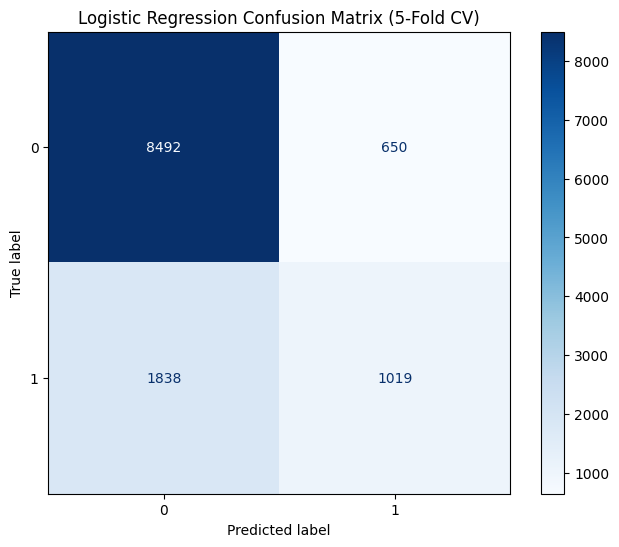

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Initialize Logistic Regression model
log_reg = LogisticRegression(random_state=123, solver='liblinear')

# Initialize Stratified K-Fold Cross-Validation
# Using the same random_state as train_test_split for consistency
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Lists to store predictions and true labels for reporting
all_y_pred_log_reg = []
all_y_test_log_reg = []

print("Training Logistic Regression with 5-fold Cross-Validation...")
for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train the model
    log_reg.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation set
    y_pred_fold = log_reg.predict(X_val_fold)

    # Store results
    all_y_pred_log_reg.extend(y_pred_fold)
    all_y_test_log_reg.extend(y_val_fold)

# Generate and print the classification report for Logistic Regression
print("\nLogistic Regression Classification Report (5-Fold CV):")
print(classification_report(all_y_test_log_reg, all_y_pred_log_reg))

# Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(all_y_test_log_reg, all_y_pred_log_reg, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Logistic Regression Confusion Matrix (5-Fold CV)')
plt.show()

Training Random Forest Classifier with 5-fold Cross-Validation...

Random Forest Classifier Classification Report (5-Fold CV):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9142
           1       0.99      0.96      0.97      2857

    accuracy                           0.99     11999
   macro avg       0.99      0.98      0.98     11999
weighted avg       0.99      0.99      0.99     11999



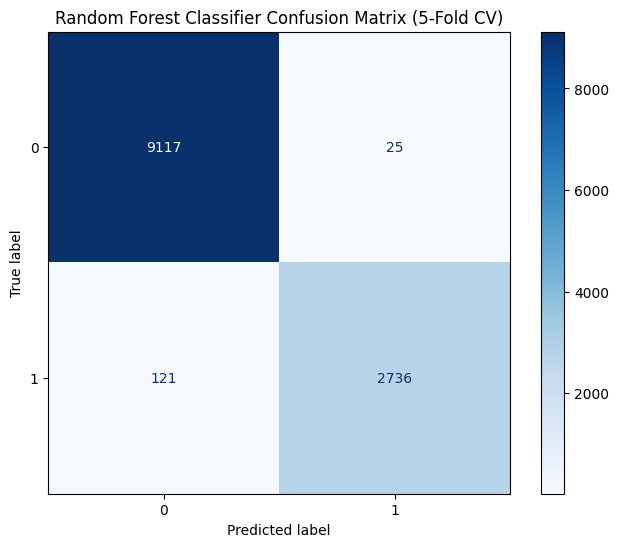

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Initialize Random Forest Classifier model
rf_clf = RandomForestClassifier(random_state=123)

# Initialize Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Lists to store predictions and true labels for reporting
all_y_pred_rf = []
all_y_test_rf = []

print("Training Random Forest Classifier with 5-fold Cross-Validation...")
for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train the model
    rf_clf.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation set
    y_pred_fold = rf_clf.predict(X_val_fold)

    # Store results
    all_y_pred_rf.extend(y_pred_fold)
    all_y_test_rf.extend(y_val_fold)

# Generate and print the classification report for Random Forest
print("\nRandom Forest Classifier Classification Report (5-Fold CV):")
print(classification_report(all_y_test_rf, all_y_pred_rf))

# Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(all_y_test_rf, all_y_pred_rf, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Random Forest Classifier Confusion Matrix (5-Fold CV)')
plt.show()

Training Gradient Boosting Classifier with 5-fold Cross-Validation...

Gradient Boosting Classifier Classification Report (5-Fold CV):
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      9142
           1       0.97      0.93      0.95      2857

    accuracy                           0.98     11999
   macro avg       0.97      0.96      0.97     11999
weighted avg       0.98      0.98      0.98     11999



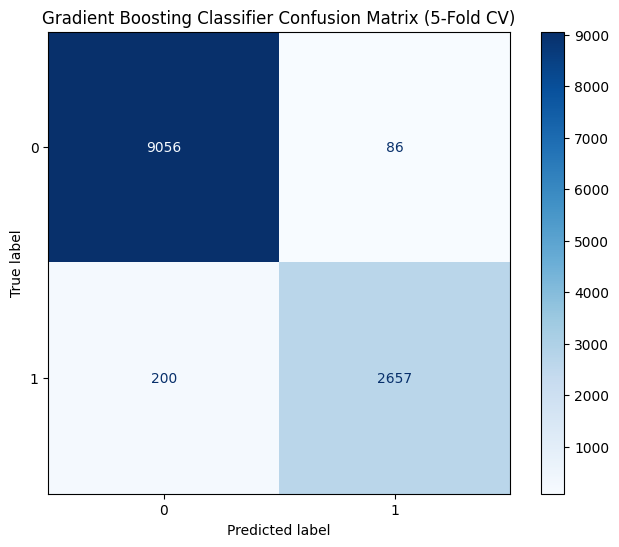

In [12]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Initialize Gradient Boosting Classifier model
gbc_clf = GradientBoostingClassifier(random_state=123)

# Initialize Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Lists to store predictions and true labels for reporting
all_y_pred_gbc = []
all_y_test_gbc = []

print("Training Gradient Boosting Classifier with 5-fold Cross-Validation...")
for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train the model
    gbc_clf.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation set
    y_pred_fold = gbc_clf.predict(X_val_fold)

    # Store results
    all_y_pred_gbc.extend(y_pred_fold)
    all_y_test_gbc.extend(y_val_fold)

# Generate and print the classification report for Gradient Boosting Classifier
print("\nGradient Boosting Classifier Classification Report (5-Fold CV):")
print(classification_report(all_y_test_gbc, all_y_pred_gbc))

# Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(all_y_test_gbc, all_y_pred_gbc, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Gradient Boosting Classifier Confusion Matrix (5-Fold CV)')
plt.show()

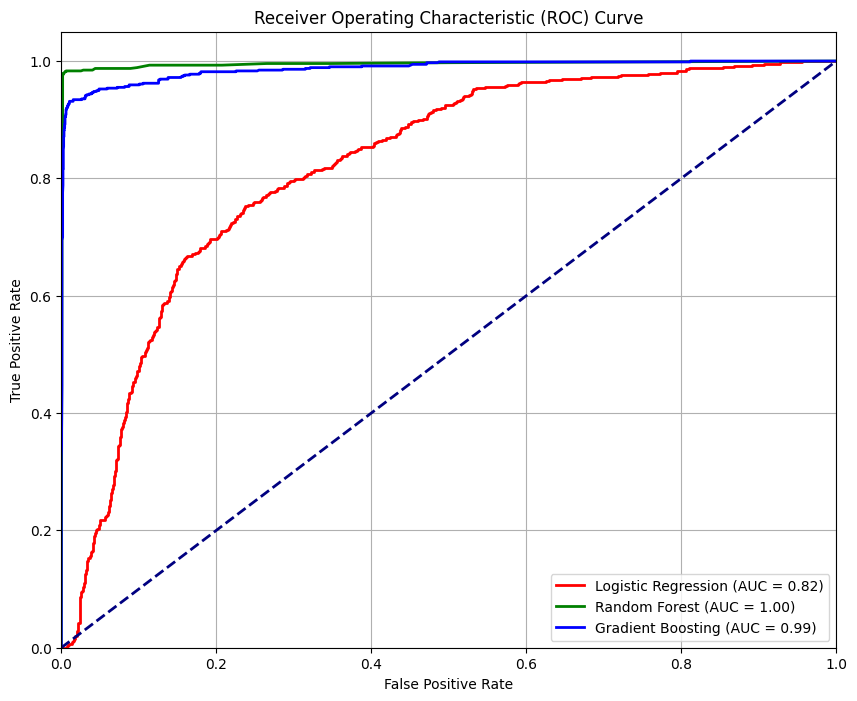

In [13]:
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Fit models on the full training data for final evaluation
log_reg.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
gbc_clf.fit(X_train, y_train)

# --- ROC Curve and AUC --- Start
plt.figure(figsize=(10, 8))

# Logistic Regression
y_pred_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_pred_proba_log_reg)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)
plt.plot(fpr_log_reg, tpr_log_reg, color='red', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log_reg:.2f})')

# Random Forest
y_pred_proba_rf = rf_clf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# Gradient Boosting Classifier
y_pred_proba_gbc = gbc_clf.predict_proba(X_test)[:, 1]
fpr_gbc, tpr_gbc, _ = roc_curve(y_test, y_pred_proba_gbc)
roc_auc_gbc = auc(fpr_gbc, tpr_gbc)
plt.plot(fpr_gbc, tpr_gbc, color='blue', lw=2, label=f'Gradient Boosting (AUC = {roc_auc_gbc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
# --- ROC Curve and AUC --- End

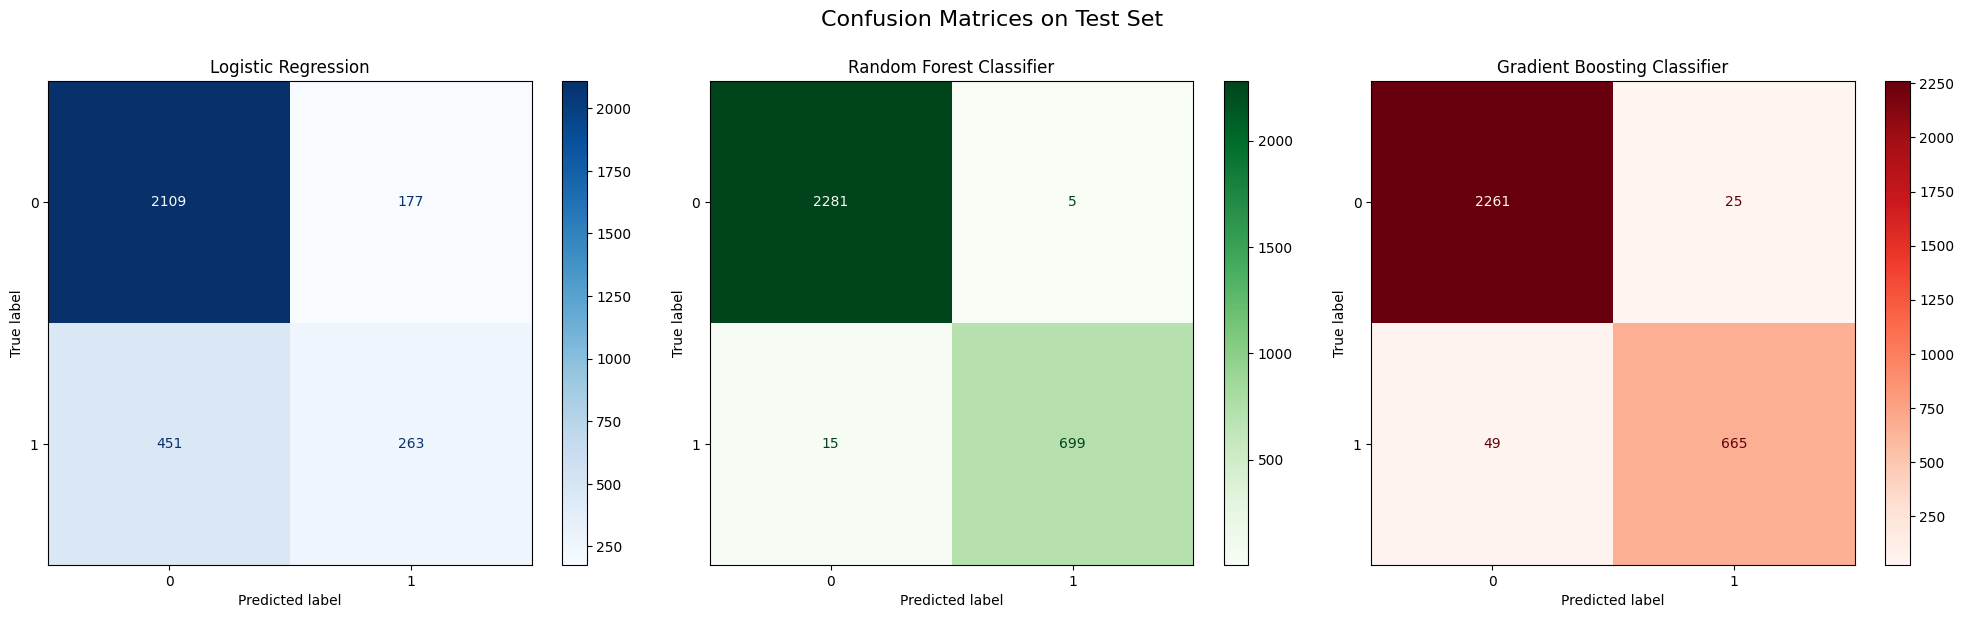

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# --- Confusion Matrices --- Start
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices on Test Set', fontsize=16)

# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title('Logistic Regression')

# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_clf, X_test, y_test, cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title('Random Forest Classifier')

# Gradient Boosting Classifier Confusion Matrix
ConfusionMatrixDisplay.from_estimator(gbc_clf, X_test, y_test, cmap=plt.cm.Reds, ax=axes[2])
axes[2].set_title('Gradient Boosting Classifier')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()
# --- Confusion Matrices --- End

### Explaining Recall vs. Precision for Employee Turnover Prediction

When evaluating a model for employee turnover prediction, the choice between **Recall** and **Precision** depends heavily on the business implications of each type of error.

*   **Recall (Sensitivity or True Positive Rate):**
    *   **Definition:** The proportion of actual positive cases (employees who *will* leave) that were correctly identified by the model. It answers the question: "Out of all employees who actually left, how many did our model correctly predict would leave?"
    *   **Formula:** `True Positives / (True Positives + False Negatives)`
    *   **Business Impact of False Negatives (Low Recall):** A False Negative occurs when the model predicts an employee will *stay*, but they actually *leave*. This is a significant issue in employee turnover prediction because it means the company was blindsided by a departure. They missed an opportunity to intervene, offer retention incentives, or prepare for the loss of talent. High False Negatives can lead to unexpected costs, productivity loss, and disruption.

*   **Precision (Positive Predictive Value):**
    *   **Definition:** The proportion of positive predictions (employees the model predicted *would* leave) that were actually correct. It answers the question: "Out of all employees our model predicted would leave, how many actually did leave?"
    *   **Formula:** `True Positives / (True Positives + False Positives)`
    *   **Business Impact of False Positives (Low Precision):** A False Positive occurs when the model predicts an employee will *leave*, but they actually *stay*. This means the company might unnecessarily implement retention strategies, offer incentives, or engage in discussions with an employee who had no intention of leaving. While potentially leading to wasted resources or slight awkwardness, the damage is generally less severe than a False Negative.

**Which metric to prioritize for Employee Turnover Prediction?**

In the context of employee turnover, **Recall is generally more critical to prioritize than Precision.**

*   **Why Recall?** The primary goal is often to identify as many at-risk employees as possible so that proactive measures can be taken to retain them. Missing an employee who is about to leave (False Negative) can have far greater negative consequences (loss of institutional knowledge, recruitment costs, impact on team morale, project delays) than mistakenly identifying an employee as at-risk when they are not (False Positive).
    *   It is usually more tolerable to spend some resources on an employee who wasn't planning to leave (False Positive) if it means catching most of the employees who genuinely are (True Positives), thus preventing costly and disruptive departures.

*   **Balancing Act:** While Recall is often prioritized, Precision still matters. An extremely low Precision could lead to too many wasted resources or damage employee trust if too many employees are falsely flagged as flight risks. Therefore, a good model will aim for a high Recall while maintaining a reasonable level of Precision. The **F1-score**, which is the harmonic mean of Precision and Recall, is often a good combined metric to consider when there is an uneven class distribution and both False Positives and False Negatives are important.

**Conclusion:** For employee turnover, we want to minimize the number of employees who leave without our intervention. Therefore, ensuring the model has a high **Recall** for the 'left' class (the positive class) is usually the most important objective, even if it comes with a slight trade-off in Precision.

In [15]:
import pandas as pd

# Using the Random Forest Classifier as the best model for prediction
# (Assuming rf_clf was trained in a previous cell)
# If you rerun this, make sure rf_clf is fitted to X_train, y_train first.
# For consistency, I will refit the model here although it was already fitted for ROC curve calculation.
rf_clf.fit(X_train, y_train)

# Predict the probability of turnover (class 1) for the test set
turnover_probabilities = rf_clf.predict_proba(X_test)[:, 1]

# Create a DataFrame to display the employee IDs and their predicted turnover probabilities
# Assuming X_test has an index that corresponds to the original DataFrame's index if available,
# or simply create a new index for the test set results.

# For demonstration, let's create a DataFrame with the probabilities and the true 'left' status
# Note: X_test doesn't have an 'employee ID' column in this setup, so we'll just use its index.

prediction_df = pd.DataFrame({
    'actual_left': y_test,
    'predicted_probability_of_leaving': turnover_probabilities
})

# Display the first few predictions
print("Predicted Turnover Probabilities for Test Employees:")
display(prediction_df.head())

# You can also analyze employees with high probability of leaving
high_risk_employees = prediction_df[prediction_df['predicted_probability_of_leaving'] > 0.7].sort_values(by='predicted_probability_of_leaving', ascending=False)
print("\nEmployees with high predicted probability of leaving (prob > 0.7):")
display(high_risk_employees.head())

Predicted Turnover Probabilities for Test Employees:


,actual_left,predicted_probability_of_leaving
10627,0,0.00
2703,0,0.45
6059,0,0.00
3258,0,0.00
4565,0,0.00



Employees with high predicted probability of leaving (prob > 0.7):


,actual_left,predicted_probability_of_leaving
14487,1,1.0
14892,1,1.0
14984,1,1.0
1821,1,1.0
371,1,1.0


### Suggested Retention Strategies for Targeted Employees

Based on the insights derived from our Exploratory Data Analysis and K-Means Clustering of employees who left, we can propose targeted retention strategies:

1.  **Address Burnout for Overworked Employees (Cluster 2 - Low Satisfaction, High Evaluation & Employees with 6-7 Projects):**
    *   **Insight:** These are high-performing employees who are likely dissatisfied due to workload or lack of work-life balance, as indicated by high evaluation scores but low satisfaction, and a high number of projects.
    *   **Strategy:** Implement workload balancing initiatives. Review project assignments to prevent employees from being consistently assigned 6-7 projects. Provide resources for stress management, mental health support, and encourage regular breaks and vacations. Recognize and reward their high performance to improve satisfaction. Conduct stay interviews to understand specific stressors and address them.

2.  **Improve Engagement and Support for Disengaged Employees (Cluster 0 - Low Satisfaction, Low Evaluation):**
    *   **Insight:** This group shows low satisfaction and low performance, suggesting a lack of engagement or fit within their roles.
    *   **Strategy:** Provide targeted training and development opportunities to improve skills and confidence. Conduct performance reviews with a focus on constructive feedback and goal setting. Implement mentorship programs. Investigate root causes of low satisfaction through employee surveys or one-on-one meetings. Consider job redesign or internal mobility options if a better fit can be found within the company.

3.  **Investigate External Factors for High Performers (Cluster 1 - High Satisfaction, High Evaluation - but still left):**
    *   **Insight:** This group is the most perplexing, as they were satisfied and performed well but still chose to leave. Their departure might be due to external factors not captured in our data (e.g., better career opportunities, higher compensation elsewhere, family relocation, retirement).
    *   **Strategy:** Conduct thorough exit interviews (if not already implemented) to gather detailed reasons for departure. Analyze market compensation and benefits to ensure competitiveness. Foster a strong company culture that emphasizes career growth paths and internal opportunities to make staying a more attractive option. For those identified with high probability of leaving, proactive career development discussions can be initiated.

4.  **Optimize Project Load (General Strategy):**
    *   **Insight:** Employees with 2 projects showed high retention, while those with 6-7 projects showed high turnover. The majority had 3-5 projects.
    *   **Strategy:** Monitor project allocation closely. Aim for an optimal project load (e.g., 2-5 projects) to maximize productivity and minimize burnout. Develop clear guidelines for project managers on how to assign and manage projects to prevent overwhelming employees.

5.  **Proactive Intervention based on Prediction:**
    *   **Insight:** The predictive model identifies employees with a high probability of leaving.
    *   **Strategy:** For employees flagged by the model as high-risk, initiate individualized check-ins with managers or HR. These conversations should be supportive, aiming to understand their current state, potential concerns, and to offer support or discuss career aspirations. This allows for targeted interventions before a decision to leave is made.

In [16]:
# Define the risk zone thresholds
def assign_risk_zone(probability):
    if probability < 0.20:
        return 'Safe Zone (Green)'
    elif 0.20 <= probability < 0.60:
        return 'Low-Risk Zone (Yellow)'
    elif 0.60 <= probability < 0.90:
        return 'Medium-Risk Zone (Orange)'
    else:
        return 'High-Risk Zone (Red)'

# Apply the function to create the 'risk_zone' column
prediction_df['risk_zone'] = prediction_df['predicted_probability_of_leaving'].apply(assign_risk_zone)

print("Distribution of employees across risk zones:")
display(prediction_df['risk_zone'].value_counts())

print("\nFirst 10 predictions with assigned risk zones:")
display(prediction_df.head(10))

Distribution of employees across risk zones:


,count
risk_zone,
Safe Zone (Green),2244
High-Risk Zone (Red),635
Medium-Risk Zone (Orange),64
Low-Risk Zone (Yellow),57



First 10 predictions with assigned risk zones:


,actual_left,predicted_probability_of_leaving,risk_zone
10627,0,0.00,Safe Zone (Green)
2703,0,0.45,Low-Risk Zone (Yellow)
6059,0,0.00,Safe Zone (Green)
3258,0,0.00,Safe Zone (Green)
4565,0,0.00,Safe Zone (Green)
4991,0,0.01,Safe Zone (Green)
13976,0,0.01,Safe Zone (Green)
9427,0,0.00,Safe Zone (Green)
7173,0,0.00,Safe Zone (Green)
13412,0,0.01,Safe Zone (Green)


### Retention Strategies for Each Risk Zone:

Based on the categorization of employees into different risk zones using their predicted probability of leaving, here are tailored retention strategies:

1.  **Safe Zone (Green) (Score < 20%):**
    *   **Insight:** These employees have a very low predicted probability of leaving. They are likely engaged and satisfied.
    *   **Strategy:** Maintain status quo. Continue with regular engagement activities, career development opportunities, and performance recognition. While low risk, it's still important not to become complacent. Regular pulse surveys can help ensure their continued satisfaction and engagement.

2.  **Low-Risk Zone (Yellow) (20% < Score < 60%):**
    *   **Insight:** These employees have a moderate probability of leaving. There might be underlying issues that are not critical but could escalate if unaddressed.
    *   **Strategy:** Implement proactive check-ins. Managers should schedule informal one-on-one meetings to discuss career aspirations, work-life balance, and any minor frustrations. Offer small growth opportunities, mentorship, or skill-development programs to boost engagement. Monitor their sentiment through occasional, targeted surveys.

3.  **Medium-Risk Zone (Orange) (60% < Score < 90%):**
    *   **Insight:** This group has a significant probability of leaving. There are likely clear factors contributing to their potential departure, which may include aspects identified in our earlier clustering (e.g., workload, satisfaction, evaluation).
    *   **Strategy:** Initiate targeted interventions. HR and managers should collaborate to conduct 'stay interviews' to understand specific concerns and offer solutions. This could involve workload adjustments, role changes, advanced training, or addressing compensation/benefits concerns if market analysis suggests they are underpaid. Focus on addressing any identified root causes of dissatisfaction or burnout from the EDA and clustering results.

4.  **High-Risk Zone (Red) (Score > 90%):**
    *   **Insight:** These employees are highly likely to leave. Immediate and decisive action is required to prevent their departure.
    *   **Strategy:** Implement urgent and personalized retention efforts. This might involve direct intervention from senior management or HR, offering significant incentives (e.g., promotion, salary increase, new projects, flexible work arrangements) based on their value to the company. Be prepared for frank conversations about their dissatisfaction and explore all possible avenues to re-engage them. In some cases, it might be about understanding their motivations and ensuring a smooth transition if retention isn't possible, while trying to gather maximum insights from their departure.